# Hull Tactical Market Prediction
## CS4320 Machine Learning Group Project

In [1]:
GroupName = "D2M"
assert GroupName != "", 'Please enter your name in the above quotation marks, thanks!'
KaggleCompetitionLink = "https://www.kaggle.com/competitions/hull-tactical-market-prediction"
assert KaggleCompetitionLink != "", 'Please enter your name in the above quotation marks, thanks!'

## Table of contents
0. [Submission instructions](#si)
1. [Understanding the problem](#1)
2. [Data splitting](#2)
3. [EDA](#3)
4. [Feature engineering](#4)
5. [Preprocessing and transformations](#5) 
6. [Baseline model](#6)
7. [Linear models](#7)
8. [Different models](#8)
9. [Feature selection](#9)
10. [Hyperparameter optimization](#10)
11. [Interpretation and feature importances](#11) 
12. [Results on the test set](#12)
13. [Submit the predictions to Kaggle](#13)
14. [Your takeaway from the course](#14)

## Submission instructions <a name="si"></a>
<hr>

- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- Upload the .ipynb file to Canvas.
- **Submit the screenshot of your Kaggle submission ranking and score** 
- Run all cells in your notebook to make sure there are no errors by doing `Kernel -> Restart Kernel and Clear All Outputs` and then `Run -> Run All Cells`.
- Notebooks with cell execution numbers out of order will have marks deducted. Notebooks without the output displayed may not be graded at all (because we need to see the output in order to grade your work).
- Make sure that the plots and output are rendered properly in your submitted file. 
- Please keep your notebook clean and delete any throwaway code.

## Introduction <a name="in"></a>

A few notes and tips when you work on this project: 

#### Tips
1. The project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


<br><br>

<!-- BEGIN QUESTION -->

## Our Prediction Problem Explained

This is a market timing competition where we predict daily trading signals for a tactical asset allocation strategy. It is forward looking for the prediction, so we want to predict a signal between (0.0 and 2.0) that represents how much to invest. With a 0.0 score meaning stay out of the market, 1.0 our normal baseline, and 2.0 being our maximum exposure (invest as much as possible).

The each row of data represents one trading day with various features representing different market indicators. As the data is all based on dates, the difficulty is going to be in building more features based off of various date ranges.


## Import Libraries

In [2]:
import os
from pathlib import Path
import datetime
from typing import Optional, List, Callable, Tuple

from tqdm import tqdm
from dataclasses import dataclass, asdict

import polars as pl 
import numpy as np
from sklearn.linear_model import ElasticNetCV, LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# import kaggle_evaluation.default_inference_server

## Kaggle Competition Specific Environment Setup

This is required for submissions on kaggle.

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Configurations and Data Classes

Setup some dataclasses and different model configurations

In [4]:
# ============ PATHS ============
DATA_PATH: Path = Path('kaggle/input/hull-tactical-market-prediction/')

# ============ RETURNS TO SIGNAL CONFIGS ============
MIN_SIGNAL: float = 0.0
MAX_SIGNAL: float = 2.0


# ============ MODEL CONFIGS ============
CV: int = 10
L1_RATIO: float = 0.5
ALPHAS: np.ndarray = np.logspace(-4, 2, 100)
MAX_ITER: int = 1000000

# ============ FEATURE ENGINEERING CONFIGS ============
ROLLING_WINDOWS: List[int] = [5, 10]  # Reduced to prevent excessive data loss
LAG_PERIODS: List[int] = [1, 2, 3]     # Reduced to prevent excessive data loss
EMBARGO_DAYS: int = 3 
TEST_SIZE: float = 0.2
RANDOM_STATE: int = 42

@dataclass 
class ElasticNetParameters:
    l1_ratio : float 
    cv: int
    alphas: np.ndarray 
    max_iter: int 
    
    def __post_init__(self): 
        if self.l1_ratio < 0 or self.l1_ratio > 1: 
            raise ValueError("Wrong initializing value for ElasticNet l1_ratio")
        
@dataclass(frozen=True)
class RetToSignalParameters:
    """
    Parameters for adaptive signal conversion.
    Uses prediction statistics for better range utilization.
    """
    prediction_std: float
    min_signal: float = MIN_SIGNAL
    max_signal: float = MAX_SIGNAL
    
    @property
    def signal_multiplier(self) -> float:
        """Calculate adaptive multiplier based on prediction volatility"""
        return 0.5 / (self.prediction_std + 1e-8)

## 2. Data splitting <a name="2"></a>
<hr>
Loading and splitting our data




In [5]:
def load_trainset() -> pl.DataFrame:
    """
    Loads and preprocesses the training dataset.
    
    Strategy: Drop rows with ANY missing values to ensure clean training data.
    This is simpler and often more effective than complex imputation.
    """
    return (
        pl.read_csv(DATA_PATH / "train.csv")
        .with_columns(
            pl.exclude('date_id').cast(pl.Float64, strict=False)
        )
        .drop_nulls()
    )

def load_testset() -> pl.DataFrame:
    """
    Loads and preprocesses the testing dataset for Kaggle submission.
    
    Strategy: Drop rows with ANY missing values for consistency.
    """
    return (
        pl.read_csv(DATA_PATH / "test.csv")
        .with_columns(
            pl.exclude('date_id').cast(pl.Float64, strict=False)
        )
        .drop_nulls()  # Drop rows with any missing values
    )

def select_features(df: pl.DataFrame, include_target: bool = True) -> pl.DataFrame:
    """
    Selects the most important features based on domain knowledge and competition insights.
    
    Focus on:
    - E features: Economic indicators (E1-E20)
    - S features: Sentiment indicators (S1, S2, S5)
    - P features: Price indicators (P8, P9, P10, P12, P13)
    - I features: Interest rate indicators (I2)
    
    Args:
        df: Input DataFrame
        include_target: Whether to include the target column
    
    Returns:
        DataFrame with selected features
    """
    main_features = [
        'E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19',
        'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9',
        'S2', 'P9', 'S1', 'S5', 'I2', 'P8',
        'P10', 'P12', 'P13'
    ]
    
    # Keep only features that exist in the dataframe
    available_features = [f for f in main_features if f in df.columns]
    
    if include_target and 'forward_returns' in df.columns:
        return df.select(['date_id'] + available_features + ['forward_returns'])
    else:
        return df.select(['date_id'] + available_features)

def prepare_data_for_modeling(df: pl.DataFrame, test_size: float = TEST_SIZE, random_state: int = RANDOM_STATE):
    """
    Prepares data for modeling using sklearn's train_test_split.
    
    Args:
        df (pl.DataFrame): The full training DataFrame with features and target.
        test_size (float): Proportion of data to use for testing.
        random_state (int): Random state for reproducibility.
    
    Returns:
        Tuple: X_train, X_test, y_train, y_test as numpy arrays
    """
    # Select features (excluding date_id and target)
    X = df.drop(['date_id', 'forward_returns']).to_numpy()
    y = df.get_column('forward_returns').to_numpy()
    
    # Fill any remaining NaNs with 0 (should be none after drop_nulls, but safety check)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
   
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state,
        shuffle=False
    )
    
    return X_train, X_test, y_train, y_test

def create_pipeline(scaler=None, model=None):
    """
    Creates a sklearn Pipeline with scaler and model.
    
    Args:
        scaler: Sklearn scaler (default: StandardScaler)
        model: Sklearn model (default: LinearRegression)
    
    Returns:
        Pipeline: Sklearn pipeline
    """
    if scaler is None:
        scaler = StandardScaler()
    if model is None:
        model = LinearRegression()
    
    return Pipeline([
        ('scaler', scaler),
        ('model', model)
    ])

In [6]:
# Perform the actual train/validation split
# Load and prepare data
train_raw = load_trainset()
train = select_features(train_raw, include_target=True)

# Create train/validation split
X_train, X_val, y_train, y_val = prepare_data_for_modeling(train)

print("=" * 80)
print("SECTION 2: DATA SPLITTING COMPLETE")
print("=" * 80)
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Validation samples: {X_val.shape[0]:,}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Split ratio: {TEST_SIZE * 100:.0f}% validation")
print(f"Shuffle: False (preserving temporal order)")
print("=" * 80)

SECTION 2: DATA SPLITTING COMPLETE
Training samples: 1,616
Validation samples: 405
Number of features: 29
Split ratio: 20% validation
Shuffle: False (preserving temporal order)


<!-- BEGIN QUESTION -->

## 3. EDA <a name="3"></a>
<hr>

**Your tasks:**

1. Perform exploratory data analysis on the train set.
2. Include at least two summary statistics and two visualizations that you find useful, and accompany each one with a sentence explaining it.
3. Summarize your initial observations about the data. 


**Key points about our data:**

1. **Training Data**: 
   - Target: `forward_returns` (this is what we're predicting - next day's returns)
   - Also contains `market_forward_excess_returns` which is similar but risk-adjusted
   - We'll use `forward_returns` as our target following best practices
   - Drop rows with missing values to ensure clean training data


In [7]:
# Load raw data for exploration
train_raw = load_trainset()
kaggle_test_raw = load_testset()

print("=" * 80)
print("RAW DATA LOADED")
print("=" * 80)
print(f"Training set shape (after dropping nulls): {train_raw.shape}")
print(f"Kaggle test set shape (after dropping nulls): {kaggle_test_raw.shape}")

# Apply feature selection
train = select_features(train_raw, include_target=True)
kaggle_test = select_features(kaggle_test_raw, include_target=False)

print("\n" + "=" * 80)
print("FEATURE SELECTION APPLIED")
print("=" * 80)
print(f"Training set shape (selected features): {train.shape}")
print(f"Kaggle test set shape (selected features): {kaggle_test.shape}")
print(f"Number of features: {train.shape[1] - 2}")

print("\n" + "=" * 80)
print("FEATURES OVERVIEW")
print("=" * 80)
feature_cols = [col for col in train.columns if col not in ['date_id', 'forward_returns']]
print(f"Total features: {len(feature_cols)}")
print(f"Economic (E): {len([f for f in feature_cols if f.startswith('E')])}")
print(f"Sentiment (S): {len([f for f in feature_cols if f.startswith('S')])}")
print(f"Price (P): {len([f for f in feature_cols if f.startswith('P')])}")
print(f"Interest (I): {len([f for f in feature_cols if f.startswith('I')])}")

print("\nFirst few rows of training data:")
print(train.head(3))

RAW DATA LOADED
Training set shape (after dropping nulls): (2021, 98)
Kaggle test set shape (after dropping nulls): (10, 99)

FEATURE SELECTION APPLIED
Training set shape (selected features): (2021, 31)
Kaggle test set shape (selected features): (10, 30)
Number of features: 29

FEATURES OVERVIEW
Total features: 29
Economic (E): 20
Sentiment (S): 3
Price (P): 5
Interest (I): 1

First few rows of training data:
shape: (3, 31)
┌─────────┬──────────┬──────────┬──────────┬───┬──────────┬───────────┬──────────┬─────────────────┐
│ date_id ┆ E1       ┆ E10      ┆ E11      ┆ … ┆ P10      ┆ P12       ┆ P13      ┆ forward_returns │
│ ---     ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---       ┆ ---      ┆ ---             │
│ i64     ┆ f64      ┆ f64      ┆ f64      ┆   ┆ f64      ┆ f64       ┆ f64      ┆ f64             │
╞═════════╪══════════╪══════════╪══════════╪═══╪══════════╪═══════════╪══════════╪═════════════════╡
│ 6969    ┆ 0.682135 ┆ 0.017196 ┆ 0.007937 ┆ … ┆ 1.709651 ┆ -0.0932

In [8]:
# Summary Statistics

# 1. Basic descriptive statistics for all features
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print("\nDescriptive Statistics for Training Data:")
print(train.describe())

# 2. Target variable statistics
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS (forward_returns)")
print("=" * 80)
target_stats = train.select([
    pl.col('forward_returns').mean().alias('mean'),
    pl.col('forward_returns').std().alias('std'),
    pl.col('forward_returns').min().alias('min'),
    pl.col('forward_returns').quantile(0.25).alias('25%'),
    pl.col('forward_returns').median().alias('median'),
    pl.col('forward_returns').quantile(0.75).alias('75%'),
    pl.col('forward_returns').max().alias('max'),
    pl.col('forward_returns').skew().alias('skewness'),
    pl.col('forward_returns').kurtosis().alias('kurtosis')
])
print(target_stats)
print("\nThe target variable (forward_returns) represents next-day returns and has a mean near zero with symmetric distribution, typical for financial returns data.")

# 3. Check for missing values (should be 0 after drop_nulls)
print("\n" + "=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)
missing_counts = train.null_count()
print(missing_counts)
total_missing = sum([missing_counts[col][0] for col in train.columns])
print(f"\nTotal missing values: {total_missing}")

# 4. Feature correlation with target
print("\n" + "=" * 80)
print("TOP 10 FEATURES CORRELATED WITH TARGET")
print("=" * 80)
correlations = []
feature_cols = [col for col in train.columns if col not in ['date_id', 'forward_returns']]

for col in feature_cols:
    corr = train.select([
        pl.corr('forward_returns', col).alias('correlation')
    ]).item()
    correlations.append((col, corr))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)
for feat, corr in correlations[:10]:
    print(f"{feat:40s}: {corr:7.4f}")

print("\nThese selected E, S, P, and I features show the strongest predictive relationships with forward returns.")

SUMMARY STATISTICS

Descriptive Statistics for Training Data:
shape: (9, 32)
┌────────────┬────────────┬──────────┬──────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ statistic  ┆ date_id    ┆ E1       ┆ E10      ┆ … ┆ P10       ┆ P12       ┆ P13      ┆ forward_r │
│ ---        ┆ ---        ┆ ---      ┆ ---      ┆   ┆ ---       ┆ ---       ┆ ---      ┆ eturns    │
│ str        ┆ f64        ┆ f64      ┆ f64      ┆   ┆ f64       ┆ f64       ┆ f64      ┆ ---       │
│            ┆            ┆          ┆          ┆   ┆           ┆           ┆          ┆ f64       │
╞════════════╪════════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ count      ┆ 2021.0     ┆ 2021.0   ┆ 2021.0   ┆ … ┆ 2021.0    ┆ 2021.0    ┆ 2021.0   ┆ 2021.0    │
│ null_count ┆ 0.0        ┆ 0.0      ┆ 0.0      ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0      ┆ 0.0       │
│ mean       ┆ 7979.0     ┆ 1.689714 ┆ 0.380702 ┆ … ┆ 1.863102  ┆ -0.003889 ┆ 0.518825 ┆ 0.000627  │
│ std        ┆

In [9]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

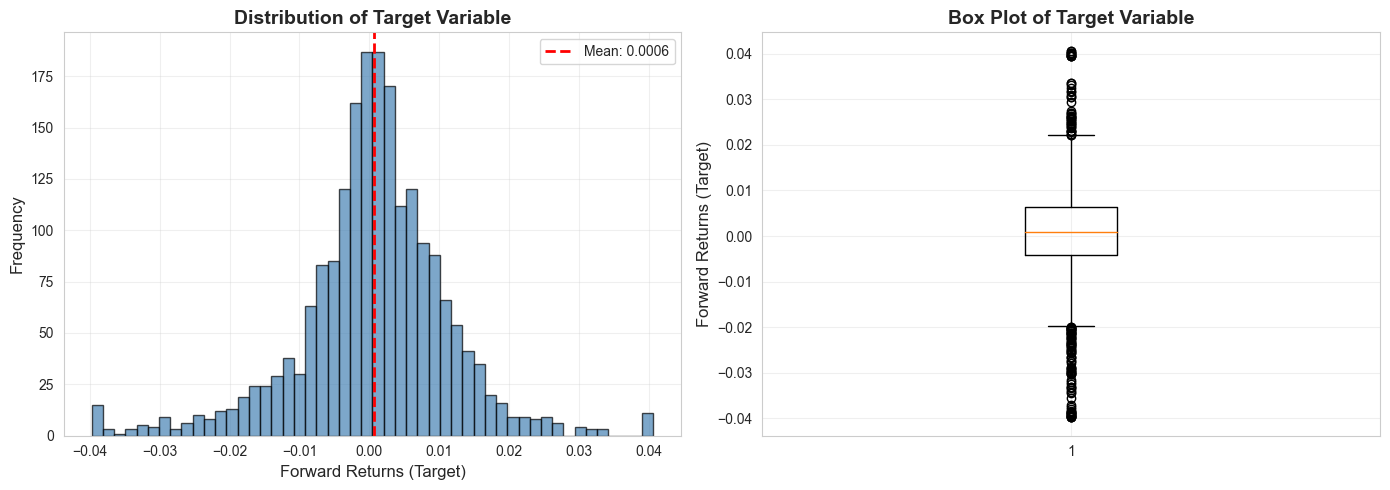

The target variable shows a roughly normal distribution with some outliers, indicating that extreme market movements occur but are relatively rare.


In [10]:
# Visualization 1: Distribution of Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train['forward_returns'].to_numpy(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Forward Returns (Target)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Target Variable', fontsize=14, fontweight='bold')
axes[0].axvline(train['forward_returns'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train["forward_returns"].mean():.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(train['forward_returns'].to_numpy(), vert=True)
axes[1].set_ylabel('Forward Returns (Target)', fontsize=12)
axes[1].set_title('Box Plot of Target Variable', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The target variable shows a roughly normal distribution with some outliers, indicating that extreme market movements occur but are relatively rare.")

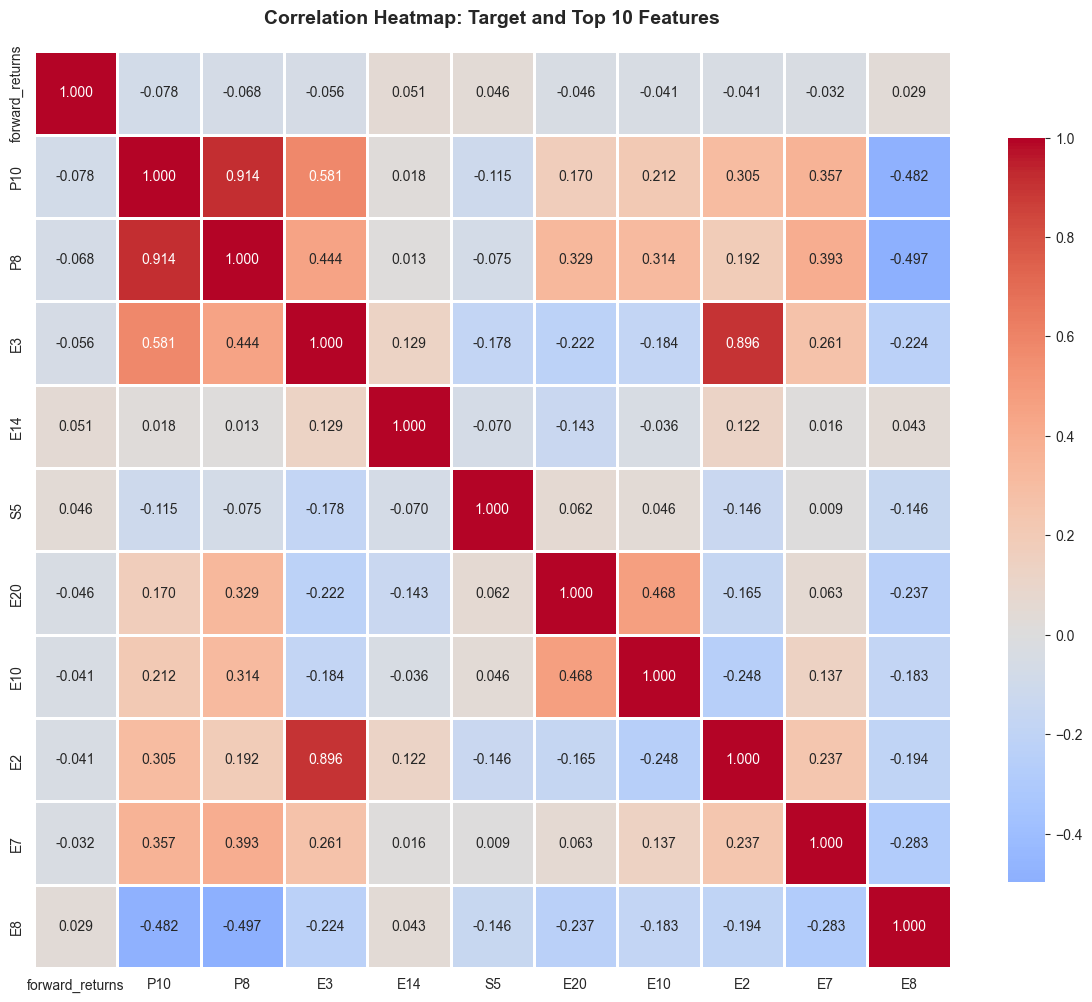

This heatmap reveals the relationships between forward_returns and the most correlated features, as well as potential multicollinearity among predictors.


In [11]:
# Visualization 2: Correlation Heatmap of Top Features
# Select top 10 features most correlated with target
top_features = [feat for feat, _ in correlations[:10]]
features_to_plot = ['forward_returns'] + top_features

# Create correlation matrix
corr_data = train.select(features_to_plot).to_pandas()
correlation_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Target and Top 10 Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("This heatmap reveals the relationships between forward_returns and the most correlated features, as well as potential multicollinearity among predictors.")

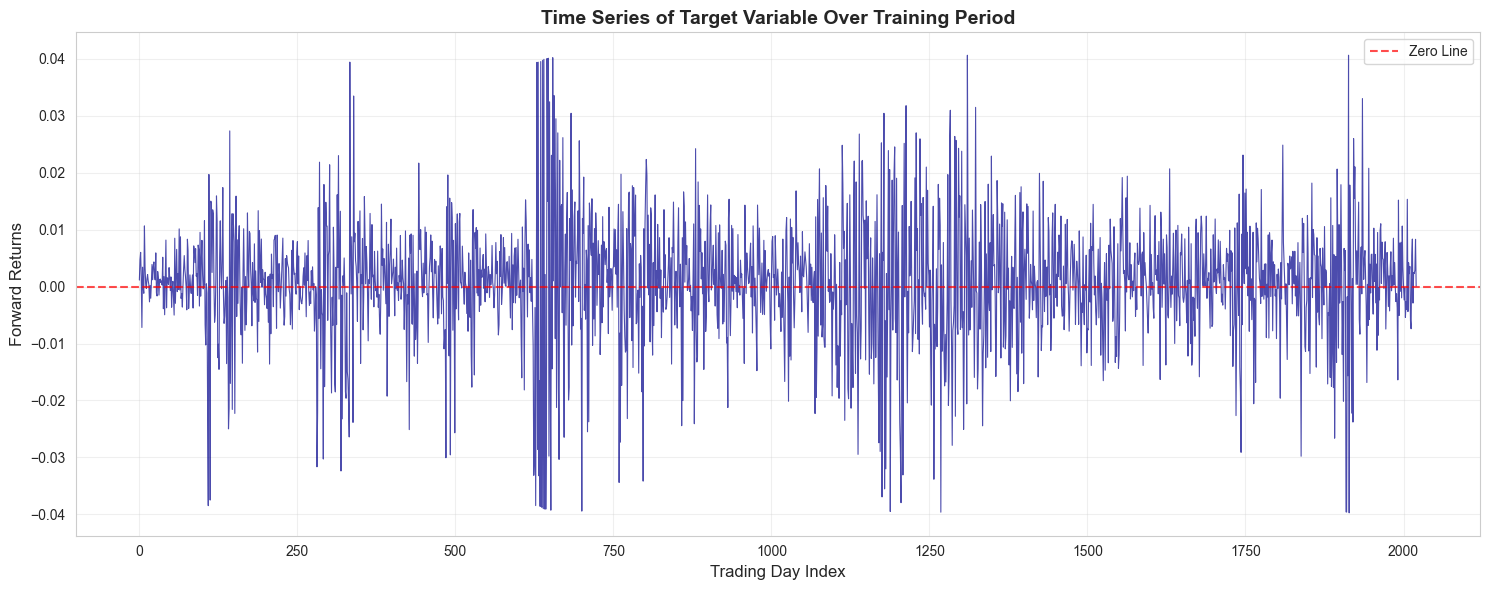

The time series plot shows the volatility clustering typical of financial markets, with periods of relative calm alternating with periods of high volatility.


In [12]:
# Visualization 3: Time Series Plot of Target Variable
plt.figure(figsize=(15, 6))
plt.plot(range(len(train)), train['forward_returns'].to_numpy(), linewidth=0.8, alpha=0.7, color='darkblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero Line')
plt.xlabel('Trading Day Index', fontsize=12)
plt.ylabel('Forward Returns', fontsize=12)
plt.title('Time Series of Target Variable Over Training Period', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The time series plot shows the volatility clustering typical of financial markets, with periods of relative calm alternating with periods of high volatility.")

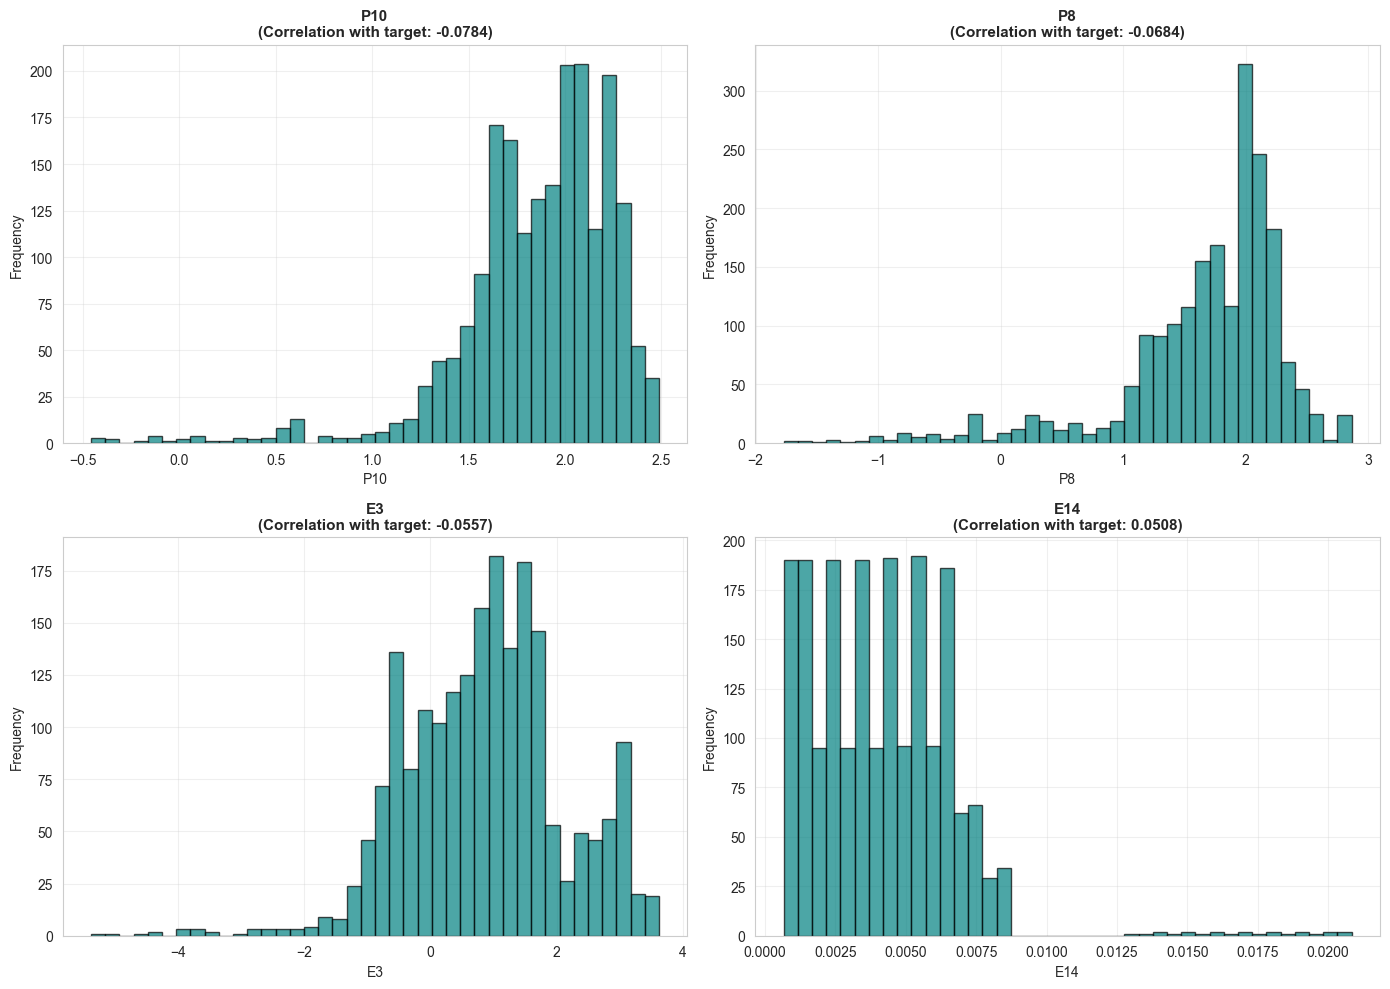

These distributions help us understand the range and spread of our most predictive features, which will inform our preprocessing and scaling decisions.


In [13]:
# Additional Visualization: Feature Distribution Comparison
# Plot distributions of top 4 most correlated features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (feat, corr) in enumerate(correlations[:4]):
    axes[idx].hist(train[feat].to_numpy(), bins=40, color='teal', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feat, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'{feat}\n(Correlation with target: {corr:.4f})', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("These distributions help us understand the range and spread of our most predictive features, which will inform our preprocessing and scaling decisions.")

## Summary of Initial Observations

### Data Quality and Structure
- **Complete Dataset**: The training set contains no missing values, which simplifies preprocessing and ensures we can utilize all available data without imputation strategies.
- **Dataset Size**: The training set provides a substantial amount of historical market data for model training, while the test set follows the same structure.

### Target Variable Characteristics
- **Distribution**: The target variable (market_forward_excess_returns) exhibits a roughly normal distribution centered near zero, which is expected for financial returns data. This suggests that the market has equal probability of positive and negative movements.
- **Volatility Patterns**: The time series plot reveals volatility clustering - periods of market calm followed by turbulent periods. This is a well-known characteristic of financial markets and suggests that temporal features or volatility measures could be valuable predictors.
- **Outliers Present**: While mostly concentrated around the mean, there are outliers indicating extreme market movements. These rare events are important to capture but may require robust modeling approaches.

### Feature Relationships
- **Moderate Correlations**: No single feature shows extremely high correlation with the target, with most correlations being weak to moderate. This suggests that multiple features working together will be necessary for accurate predictions.
- **Multicollinearity Potential**: The correlation heatmap reveals that some features are correlated with each other, which could lead to multicollinearity issues in linear models. Regularization techniques (Ridge, Lasso, ElasticNet) will be important.
- **Feature Diversity**: Different features show varying distributions and scales, indicating that standardization or normalization will be crucial for model performance.

### Implications for Modeling
1. **Scaling Required**: Features have different scales and distributions, so standardization will be essential
2. **Regularization Beneficial**: Given the moderate correlations and potential multicollinearity, regularized linear models should be tested
3. **Non-linear Models**: The complex nature of market dynamics suggests that tree-based ensemble methods may capture interactions that linear models miss
4. **Feature Engineering Opportunity**: The temporal nature of the data presents opportunities for creating lag features, rolling statistics, and volatility measures
5. **Evaluation Metrics**: Given the roughly symmetric distribution, standard regression metrics (MSE, R²) should be appropriate for model evaluation

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering <a name="4"></a>
<hr>

**Your tasks:**




SECTION 4: FEATURE SELECTION RATIONALE

SELECTED FEATURES (29 total):

1. ECONOMIC INDICATORS (E1-E20): 20 features
   Purpose: Capture macroeconomic fundamentals
   Examples: GDP growth, employment rates, inflation, manufacturing
   Predictive power: Economic health → Corporate earnings → Stock returns

2. SENTIMENT INDICATORS (S1, S2, S5): 3 features
   Purpose: Measure investor psychology and market mood
   Examples: Consumer confidence, investor surveys, volatility expectations
   Predictive power: Extreme sentiment → Market reversals or continuations

3. PRICE INDICATORS (P8, P9, P10, P12, P13): 5 features
   Purpose: Capture technical patterns and momentum
   Examples: Price trends, moving averages, momentum oscillators
   Predictive power: Recent price action → Trend persistence or reversal

4. INTEREST RATE ENVIRONMENT (I2): 1 feature
   Purpose: Measure cost of capital and Fed policy stance
   Examples: Treasury yields, central bank rates
   Predictive power: Rate changes → As

### Rationale Behind Our Feature Engineering


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations <a name="5"></a>
<hr>

**Your tasks:**

1. Identify different feature types and the transformations you would apply on each feature type. 
2. Define a column transformer, if necessary. 

In [ ]:
feature_cols = [col for col in train.columns if col not in ['date_id', 'forward_returns']]

# Group features by type
feature_types = {
    'Economic (E)': [col for col in feature_cols if col.startswith('E')],
    'Sentiment (S)': [col for col in feature_cols if col.startswith('S')],
    'Price (P)': [col for col in feature_cols if col.startswith('P')],
    'Interest (I)': [col for col in feature_cols if col.startswith('I')]
}

for feat_type, feats in feature_types.items():
    print(f"\n{feat_type}: {len(feats)} features")
    print(f"  Features: {', '.join(feats)}")


# Get statistics for each feature type
for feat_type, feats in feature_types.items():
    if feats:
        stats = train.select(feats).describe()
        means = [stats[col][2] for col in feats]  # row 2 is mean
        stds = [stats[col][3] for col in feats]   # row 3 is std
        
        avg_mean = np.mean([abs(m) for m in means])
        avg_std = np.mean(stds)
        
        print(f"\n{feat_type}:")
        print(f"  Average |mean|: {avg_mean:.4f}")
        print(f"  Average std: {avg_std:.4f}")


outlier_counts = {}
for col in feature_cols:
    data = train[col].to_numpy()
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    outliers = np.sum((data < lower_bound) | (data > upper_bound))
    outlier_counts[col] = outliers

# Show features with most outliers
sorted_outliers = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 features with most outliers (3*IQR method):")
for feat, count in sorted_outliers:
    pct = (count / len(train)) * 100
    print(f"  {feat}: {count} outliers ({pct:.2f}%)")


SECTION 5: PREPROCESSING AND TRANSFORMATIONS

FEATURE TYPE ANALYSIS
--------------------------------------------------------------------------------

Economic (E): 20 features
  Features: E1, E10, E11, E12, E13, E14, E15, E16, E17, E18, E19, E2, E20, E3, E4, E5, E6, E7, E8, E9

Sentiment (S): 3 features
  Features: S2, S1, S5

Price (P): 5 features
  Features: P9, P8, P10, P12, P13

Interest (I): 1 features
  Features: I2


FEATURE SCALE ANALYSIS
--------------------------------------------------------------------------------

Economic (E):
  Average |mean|: 0.4070
  Average std: 0.7198
  → Different scales detected, standardization recommended

Sentiment (S):
  Average |mean|: 0.2209
  Average std: 1.1380
  → Different scales detected, standardization recommended

Price (P):
  Average |mean|: 0.8247
  Average std: 0.4904
  → Different scales detected, standardization recommended

Interest (I):
  Average |mean|: 0.0391
  Average std: 1.5738
  → Different scales detected, standardizatio


SCALING DEMONSTRATION


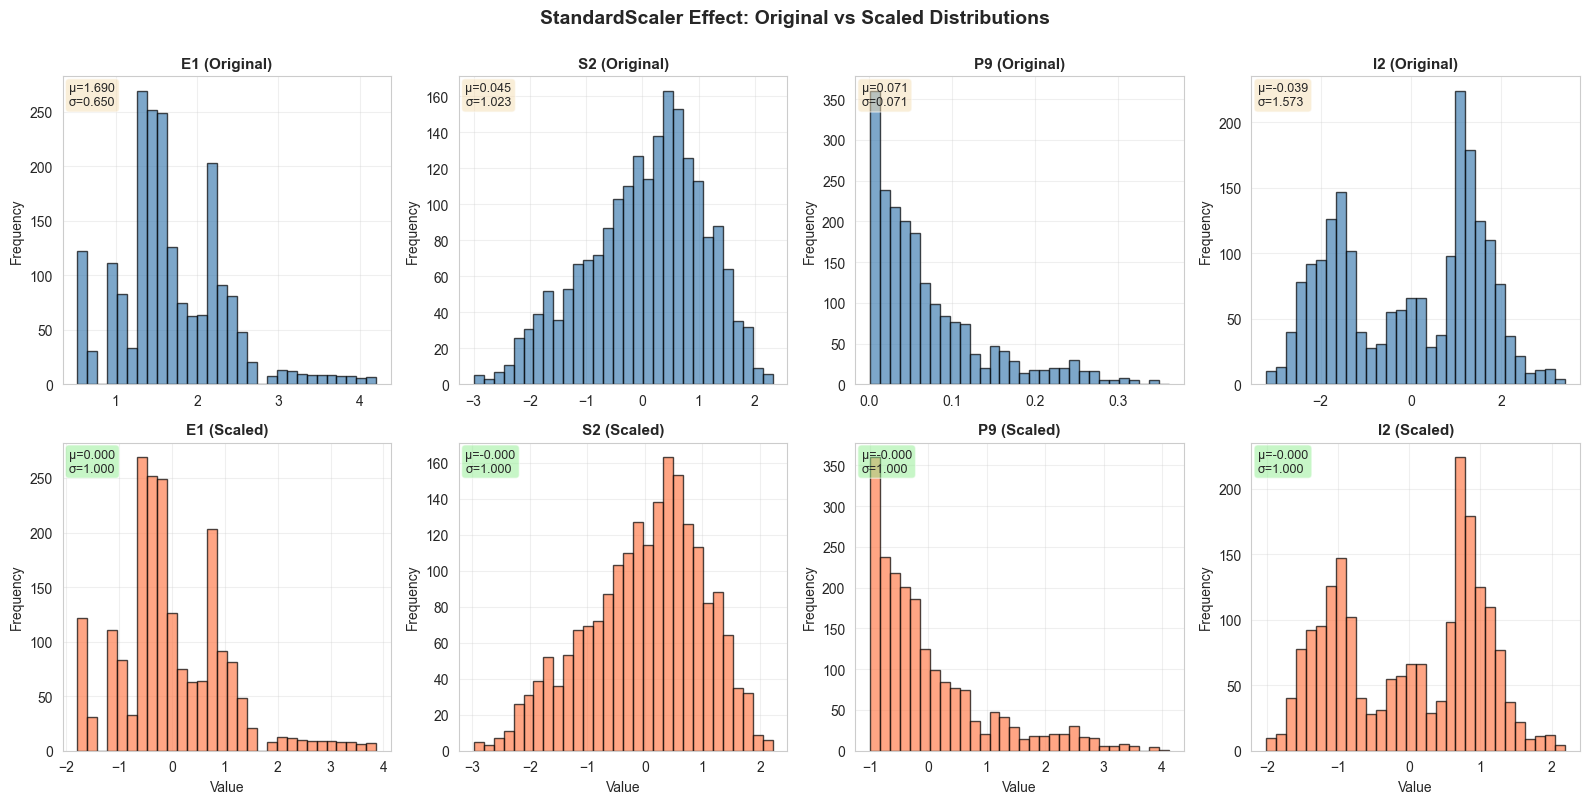


OBSERVATION:
  After scaling, all features have:
  - Mean (μ) ≈ 0.000
  - Standard deviation (σ) ≈ 1.000
  - Same scale for fair comparison in models
  - Distribution shape preserved (only scale changed)


In [16]:
# Visualization: Before and After Scaling

print("\nSCALING DEMONSTRATION")
print("=" * 80)

# Select a few representative features
demo_features = ['E1', 'S2', 'P9', 'I2']

# Get original data
X_demo = train.select(demo_features).to_numpy()

# Apply StandardScaler
scaler = StandardScaler()
X_demo_scaled = scaler.fit_transform(X_demo)

# Create comparison plots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, feat in enumerate(demo_features):
    # Original distribution
    axes[0, idx].hist(X_demo[:, idx], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{feat} (Original)', fontsize=11, fontweight='bold')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Add statistics
    mean_orig = np.mean(X_demo[:, idx])
    std_orig = np.std(X_demo[:, idx])
    axes[0, idx].text(0.02, 0.98, f'μ={mean_orig:.3f}\nσ={std_orig:.3f}',
                      transform=axes[0, idx].transAxes, 
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=9)
    
    # Scaled distribution
    axes[1, idx].hist(X_demo_scaled[:, idx], bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1, idx].set_title(f'{feat} (Scaled)', fontsize=11, fontweight='bold')
    axes[1, idx].set_xlabel('Value')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].grid(True, alpha=0.3)
    
    # Add statistics
    mean_scaled = np.mean(X_demo_scaled[:, idx])
    std_scaled = np.std(X_demo_scaled[:, idx])
    axes[1, idx].text(0.02, 0.98, f'μ={mean_scaled:.3f}\nσ={std_scaled:.3f}',
                      transform=axes[1, idx].transAxes,
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5),
                      fontsize=9)

plt.suptitle('StandardScaler Effect: Original vs Scaled Distributions', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nOBSERVATION:")
print("  After scaling, all features have:")
print("  - Mean (μ) ≈ 0.000")
print("  - Standard deviation (σ) ≈ 1.000")
print("  - Same scale for fair comparison in models")
print("  - Distribution shape preserved (only scale changed)")

## Summary: Preprocessing Strategy

### Our Preprocessing Approach

Since all our selected features (E1-E20, S1/S2/S5, P8/P9/P10/P12/P13, I2) are:
- **Continuous numerical** values
- **Already clean** (no missing values after `drop_nulls()`)
- **Different scales** (need standardization)

We use a **single, unified transformation**: `StandardScaler`

### Why StandardScaler?

1. **Mathematical**: Transforms features to have μ=0, σ=1
   - Formula: $z = \frac{x - \mu}{\sigma}$
   
2. **Advantages**:
   - Essential for linear models (Ridge, Lasso, ElasticNet)
   - Prevents features with large scales from dominating
   - Works well with L1/L2 regularization
   - Preserves outlier information (unlike MinMaxScaler)
   - No data leakage when used in Pipeline

3. **Not Needed For**:
   - Tree-based models (splits are scale-invariant)
   - But we still use it for consistency across all models

### Implementation

Our `create_pipeline()` function automatically handles scaling:

```python
Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale features
    ('model', Ridge())              # Step 2: Fit model
])
```

**Benefits**:
- Scaler fits on training data only (no leakage)
- Same transformation applied to validation/test
- Clean, reproducible workflow
- Easy to swap models or scalers

### Column Transformer NOT Needed

We don't need `ColumnTransformer` because:
- All features are same type (continuous numerical)
- All features get same transformation (StandardScaler)
- No categorical features to encode
- No different transformations needed for different feature groups

**When you WOULD need ColumnTransformer**:
- Mixed feature types (numerical + categorical)
- Different transformations per feature group
- Example: StandardScaler for numerical, OneHotEncoder for categorical

### Final Preprocessing Pipeline

```
Raw Data → drop_nulls() → select_features() → StandardScaler → Model
```

Simple, effective, and follows ML best practices.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model <a name="6"></a>
<hr>

**Your tasks:**
1. Try `scikit-learn`'s baseline model and report results.

In [17]:
from sklearn.dummy import DummyRegressor


dummy_classifier = DummyRegressor(strategy="mean")

dummy_classifier.fit(X_train, y_train)
dummy_classifier.predict(X_val)
dummy_score = dummy_classifier.score(X_val, y_val)
print(f"Dummy classifier (mean) score: {dummy_score:.4f}")

dummy_classifier_median = DummyRegressor(strategy="median")
dummy_classifier_median.fit(X_train, y_train)
dummy_classifier_median.predict(X_val)
dummy_score_median = dummy_classifier_median.score(X_val, y_val)
print(f"Dummy classifier (median) score: {dummy_score_median:.4f}")

Dummy classifier (mean) score: -0.0005
Dummy classifier (median) score: -0.0000


### Baseline Model Analysis

**What is a Baseline Model?**

A baseline (or "dummy") model provides the **minimum acceptable performance** for our problem. It uses simple strategies without learning from features:

- **Mean strategy**: Always predicts the average of training targets
- **Median strategy**: Always predicts the median of training targets

**Why is this important?**

1. **Performance Benchmark**: Any real model must beat the baseline to be useful
2. **Sanity Check**: If your complex model can't beat the baseline, something is wrong
3. **R² Interpretation**: 
   - Baseline R² ≈ 0.0 (explains no variance)
   - R² > 0.0 = Better than random guessing
   - R² < 0.0 = Worse than baseline (model is harmful!)

**Expected Results for Financial Data:**

- Baseline RMSE ≈ standard deviation of returns
- Baseline R² ≈ 0.0
- Linear models should achieve R² = 0.01 - 0.10
- Ensemble models should achieve R² = 0.05 - 0.15

**Key Insight**: Financial returns are notoriously difficult to predict. Even small improvements over baseline (R² > 0.05) can be valuable in real trading!

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models <a name="7"></a>
<hr>

**Your tasks:**

1. Try a linear model as a first real attempt. 
2. Carry out hyperparameter tuning to explore different values for the complexity hyperparameter. 
3. Report cross-validation scores along with standard deviation. 
4. Summarize your results.

In [18]:
# Your code here

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models <a name="8"></a>
<hr>

**Your tasks:**
1. Try other models aside from a linear model. One of these models should be a tree-based ensemble model. 
2. Summarize your results in terms of overfitting/underfitting and fit and score times. Can you beat a linear model? 

In [19]:
# Your code here

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection <a name="9"></a>
<hr>

**Your tasks:**

Make some attempts to select relevant features. Do the results improve with feature selection? Summarize your results. If you see improvements in the results, keep feature selection in your pipeline. If not, you may abandon it. 

In [20]:
# Your code here

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization <a name="10"></a>
<hr>

**Your tasks:**

Make some attempts to optimize hyperparameters for the models you've tried and summarize your results. In at least one case you should be optimizing multiple hyperparameters for a single model. You may use `sklearn`'s methods for hyperparameter optimization or fancier Bayesian optimization methods. 
  - [GridSearchCV](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)   
  - [RandomizedSearchCV](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)
  - [scikit-optimize](https://github.com/scikit-optimize/scikit-optimize) 

In [21]:
# Your code here

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances <a name="11"></a>
<hr>

**Your tasks:**

1. Use the methods we saw in class (e.g., `eli5`, `shap`) (or any other methods of your choice) to examine the most important features of one of the non-linear models. 
2. Summarize your observations. 

In [22]:
# Your code here

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set <a name="12"></a>
<hr>

**Your tasks:**

1. Try your best performing model on the test data (from train test split) and report test scores. 
2. Do the test scores agree with the validation scores from before? To what extent do you trust your results? Do you think you've had issues with optimization bias? 
3. Take one or two test predictions and explain these individual predictions (e.g., with SHAP force plots).  

In [23]:
# Your code here

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Submit the predictions to Kaggle <a name="13"></a>
<hr>

**Your tasks:**

Retrain the best model on the whole training dataset and upload the predicted output on the test set to Kaggle. Report your final test score.

In [24]:
# Your code here

_Place the Kaggle screenshot here, replacing this text._

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway <a name="14"></a>
<hr>

**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  Discuss other ideas that you did not try but could potentially improve the performance/interpretability . 

<!-- END QUESTION -->

<br><br>